<a href="https://colab.research.google.com/github/NnamdiOdozi/NEBIUS_MAR_2026/blob/main/Week_6_practice_session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lesson #6. PyTorch. Building and training Neural Network with Gradient Descent

## PyTorch



PyTorch is one of the most popular deep learning frameworks nowadays. "Popular" in the sense that today most code related to neural networks is written in PyTorch. What made this framework so popular is that PyTorch is very convenient to work with. As we will see further, working with PyTorch is very similar to working with Numpy. PyTorch also has very convenient and informative [documentation](https://pytorch.org/docs/stable/index.html) and [tutorials](https://pytorch.org/tutorials/).

A short introduction into deep learning frameworks:
- **Caffee, Theano, Lasagne** — are practically no longer used;
- **Tensorflow** is a framework developed by Google, which was popular until 2017-2018 before the rise of PyTorch. At that time, most code related to neural networks was written in Tensorflow. However, it was quite complex, so PyTorch quickly took over the lead.
    
    Tensorflow also has a Keras "wrapper", which makes it easier to work with neural networks. However, Keras is less flexible than PyTorch, so it cannot fully replace it.

    Also in 2019, Tensorflow 2.0 was released, in which working with neural networks was greatly simplified. But by that time, the market had already been captured by PyTorch, so Tensorflow 2.0 never became popular.
- **PyTorch**;
- **JAX eco system** — a new framework from Google, designed to replace Tensorflow.

Let's get familiar with basic blocks and syntax of PyTorch.

### torch.Tensor

The basic block of the framework is a structure called `torch.Tensor`. Tensor is an analogue of `numpy.array`, and in many way working with `torch.Tensor` is analogous to that of `numpy array`.

A tensor is the data type that all neural networks in PyTorch work with. All the weight matrices of the network layers are tensors. The data that we feed to the network as input must also be converted to the `torch.Tensor` type. And the network output, of course, will also be of `torch.Tensor` type.

Let's import Torch library and look at typical ways of creating and manipulating tensors.

In [44]:
import torch
import warnings
warnings.filterwarnings('ignore')

1. Tensors can be created from Python lists, arrays, and other containers.

In [45]:
x_list = [1., 2., 3.]
x_tensor = torch.tensor(x_list)
x_tensor

tensor([1., 2., 3.])

2. Tensors can be created using initialization functions, as in `numpy`.

In [46]:
# tensor of zeros of a shape (2, 3)
zeros_tensor = torch.zeros(2, 3)
zeros_tensor

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [47]:
# tensor of ones of a shape (2, 3)
ones_tensor = torch.ones(2, 3)
ones_tensor

tensor([[1., 1., 1.],
        [1., 1., 1.]])

In [48]:
# identity matrix of a shape (6, 6)
eye_tensor = torch.eye(6)
eye_tensor

tensor([[1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1.]])

3. In general, `torch.Tensor` supports almost all the methods that Numpy arrays do.

Let's create two 2-dimentional tensors:

In [49]:
x_tensor = torch.tensor([
    [1, 2],
    [3, 4]
])

y_tensor = torch.tensor([
    [-10, 3],
    [5, -4]
])

In [50]:
# addition
x_tensor + y_tensor

tensor([[-9,  5],
        [ 8,  0]])

In [51]:
# matrix multiplication
x_tensor @ y_tensor

tensor([[  0,  -5],
        [-10,  -7]])

In [52]:
# analogue of np.concatenate([x_tensor, y_tensor], axis=1)
torch.cat([x_tensor, y_tensor], dim=0)

tensor([[  1,   2],
        [  3,   4],
        [-10,   3],
        [  5,  -4]])

4. Tensors can be converted back to Numpy format:

In [53]:
x_tensor = torch.tensor([
    [1, 2],
    [3, 4]
])

x_numpy = x_tensor.numpy()
x_numpy

array([[1, 2],
       [3, 4]])

## Neural Network in PyTorch

Let's learn how to create a fully connected neural network in Pytorch.

Neural networks in Pytorch are created in a constructor way: there is a set of standard blocks from which we can assemble the final model. The simplest of these blocks are Linear (fully-connected) layers and activation functions. In the following lessons, we will also get acquainted with other types of blocks that can be built into the network architecture.

Let's remind ourselves how a fully connected neural network is structured:



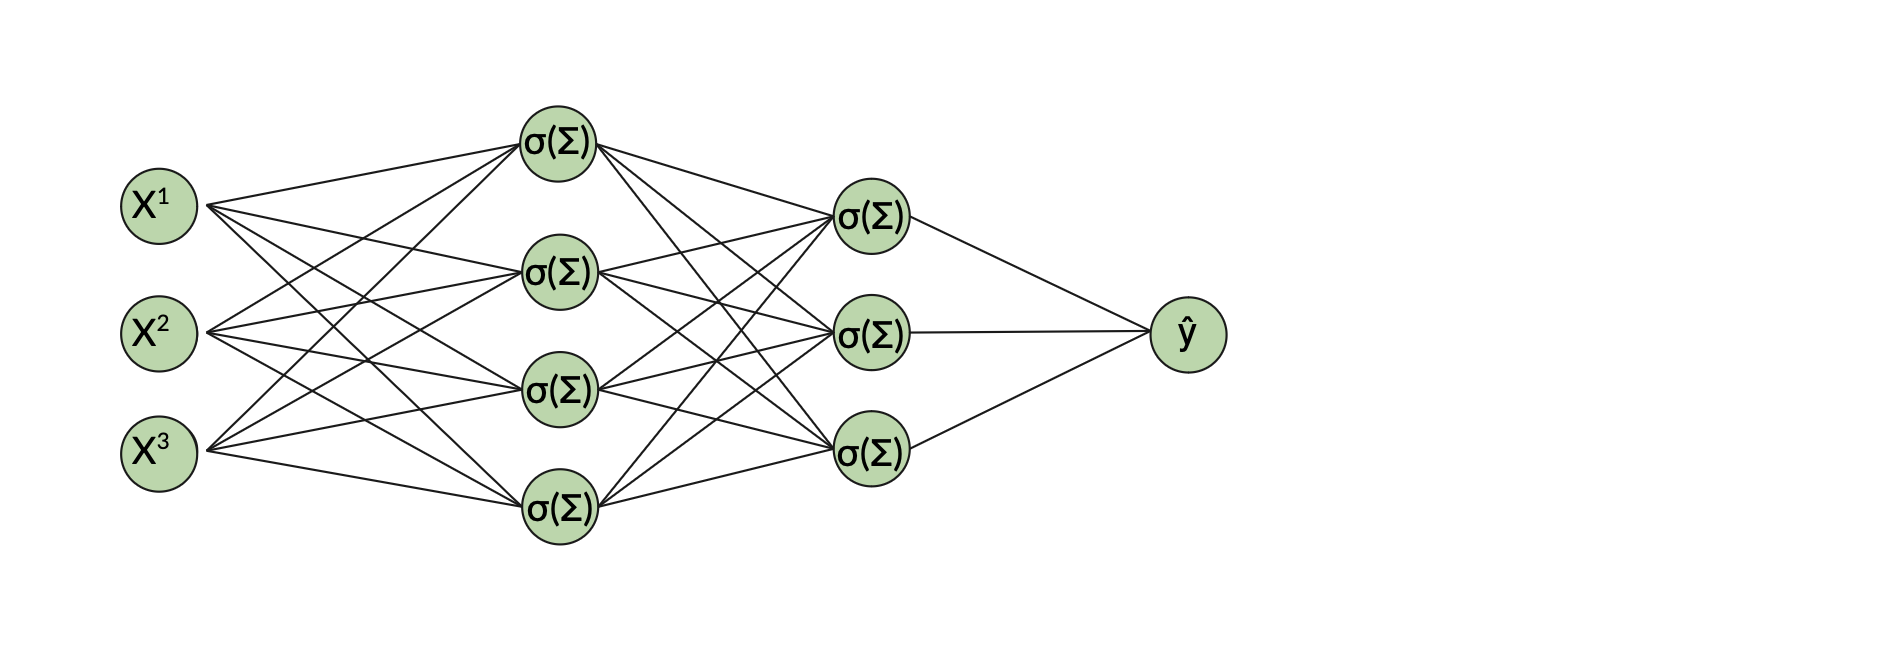

$$\widehat{y} = \sigma(W_3^T \sigma(W_2^T \sigma(W_1^TX + b_1 ) + b_{2}) + b_{3})$$

Each fully connected layer is a combination of a linear transformation $\widehat{c} = WX + b$ and some activation function $\sigma(\widehat{c})$:
- First, the input vector $X$ is multiplied by the matrix $W$ and the bayes term $b$ is added to the result:

    $$\widehat{c} = WX + b$$
- The obtained result is then passed through the activation function. The output is fed as an input vector to the next layer of the network.
    
    $$\sigma(\widehat{c})$$

A neural network is defined as a list of similar transformations following each other.

Let's learn how to define a linear transformation and an activation function. And then combine them to create a fully connected neural network.

A layer representing a linear transformation is defined using the `torch.nn.Linear` class. Let's create a layer with 5 input and 3 output neurons.

In [11]:
import torch
import warnings
warnings.filterwarnings('ignore')

In [12]:
import torch.nn as nn

n = 5
m = 3
linear_layer = nn.Linear(n, m)

In [13]:
linear_layer

Linear(in_features=5, out_features=3, bias=True)

Next, the activation function. Many well-known activation functions are implemented in the `nn` module and duplicated in the `nn.functional` module. Let's choose one of them, for example, the hyperbolic tangent (tanh):

In [14]:
import torch.nn.functional as F

# Two variants can be used. First one:
# activation = F.tanh
# or the more preferable one:
activation = nn.Tanh()

In [15]:
x_tensor = torch.tensor([
    [1, 2],
    [3, 4]
])
activation(x_tensor)

tensor([[0.7616, 0.9640],
        [0.9951, 0.9993]])

**Note:** the second option of declaring the activation function (using the `nn` module) is preferable, since using functions directly from `torch.nn.functional` can sometimes lead to not quite correct operation of complex models. It is safer and more correct to use classes from `torch.nn`. However, very often you can find the use of objects from `torch.nn.functional` on various resources dedicated to `Pytorch`, so we consider it necessary that you are aware about this method of using activation functions.

Now the fow of some input tensor through such a fully connected layer can be defined using a sequence of commands:

In [16]:
random_input = torch.rand(5)

z = linear_layer(random_input)
output = activation(z)
output

tensor([-0.2163,  0.6276,  0.2286], grad_fn=<TanhBackward0>)

Pay attention to `grad_fn=<TanhBackward0>`. Such a thing will appear on all tensors that are trainable parameters in the neural network. This means that a gradient will be calculated for this tensor during the network training process, with the help of which the tensor values ​​will be then updated. We will talk about the network training process in more detail later in this lesson.

Now let's assemble a neural network from `Linear` and `Tanh` blocks. The easiest way to concatenate several blocks is to use the `nn.Sequential` module. This class will allow us to combine several blocks into one container so that when this container is applied to some tensor, this tensor will pass through all the blocks in a specified order. That is, this way we can get a neural network with sequential Linear and Tanh layers.

In [17]:
FF_layer = nn.Sequential(
    linear_layer,
    activation
)
FF_layer(random_input)

tensor([-0.2163,  0.6276,  0.2286], grad_fn=<TanhBackward0>)

We got exactly the same result as in the cell above. Let's now build a fully connected neural network in the same way to solve some simple problem. For example, let's try to fit a cosine function using neural net.

### Fully-connected neural network for cosine function approximation

First of all, let's define a one-dimensional dataset:

In [18]:
X = torch.normal(mean=torch.zeros((1000, 1)), std= 2)
Y = torch.cos(X)

Let's visualize our data:

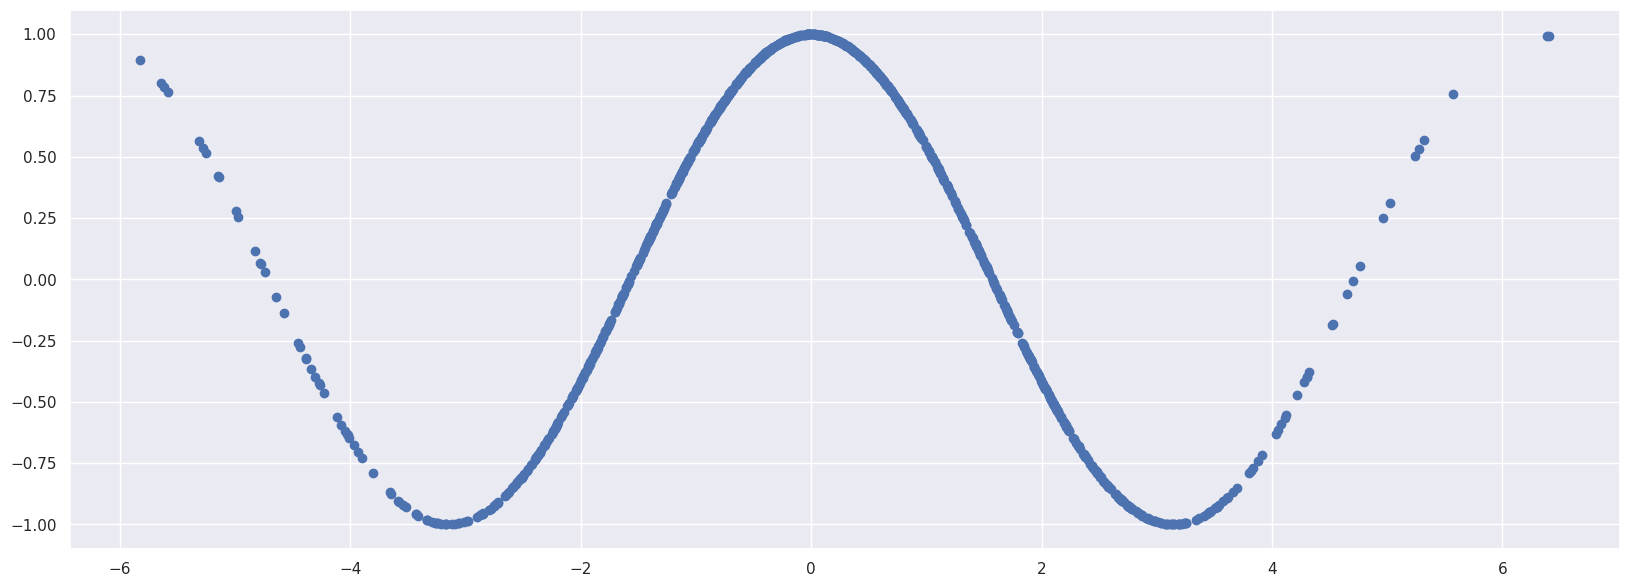

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

plt.figure(figsize=(20,7))
plt.scatter(x=X, y=Y);

Let's define a neural network with three layers. Let it be five neurons in both hidden layers. As an activation function, we'll choose the hyperbolic tangent, as in the examples above.

This is what the structure of our network will be:

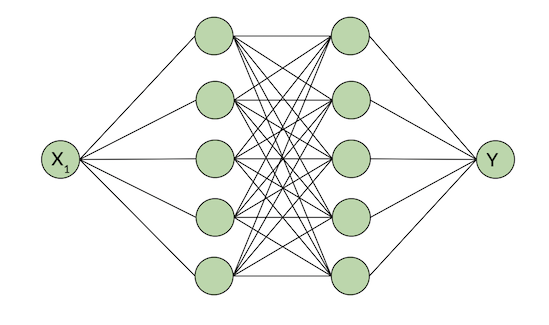

In [20]:
import torch.nn as nn
NN = nn.Sequential(nn.Linear(1, 5, bias=True),
                   nn.Tanh(),
                   nn.Linear(5, 5, bias=True),
                   nn.Tanh(),
                   nn.Linear(5, 1, bias=True),
                   )

Let's now see what our untrained neural network can do:

**Note 1:** in line 8 of the code cell above we used the `.view()` method. `.view()` is an alternative to the `.reshape()` method, which allows to change the dimensionality of a tensor without changing the data in it. Here we used it to turn an input data vector of length $n$ into a matrix of size $(n, 1)$. This formality is necessary for the tensor to correctly pass through our transformations. The thing is that a neural network (and any other machine learning models) accept data as input in the form of a matrix of size $(n, k)$, where $n$ is the number of data elements, $k$ is the number of features for each data element. In our case, each element has 1 feature (a coordinate along the OX axis). And we kind of make an elements-features matrix, in which there are $n$ elements, and each element has 1 feature.

**Note 2:** In line 9 of the code cell above we executed a combination of the tensor methods `.detach().numpy()`. The `.detach()` function is needed to extract the tensor from the computation graph of the neural network. Roughly speaking, the output of the neural network is still part of the computation graph of the network, and in order to translate this tensor into `numpy`, we first need to separate it from the network graph.

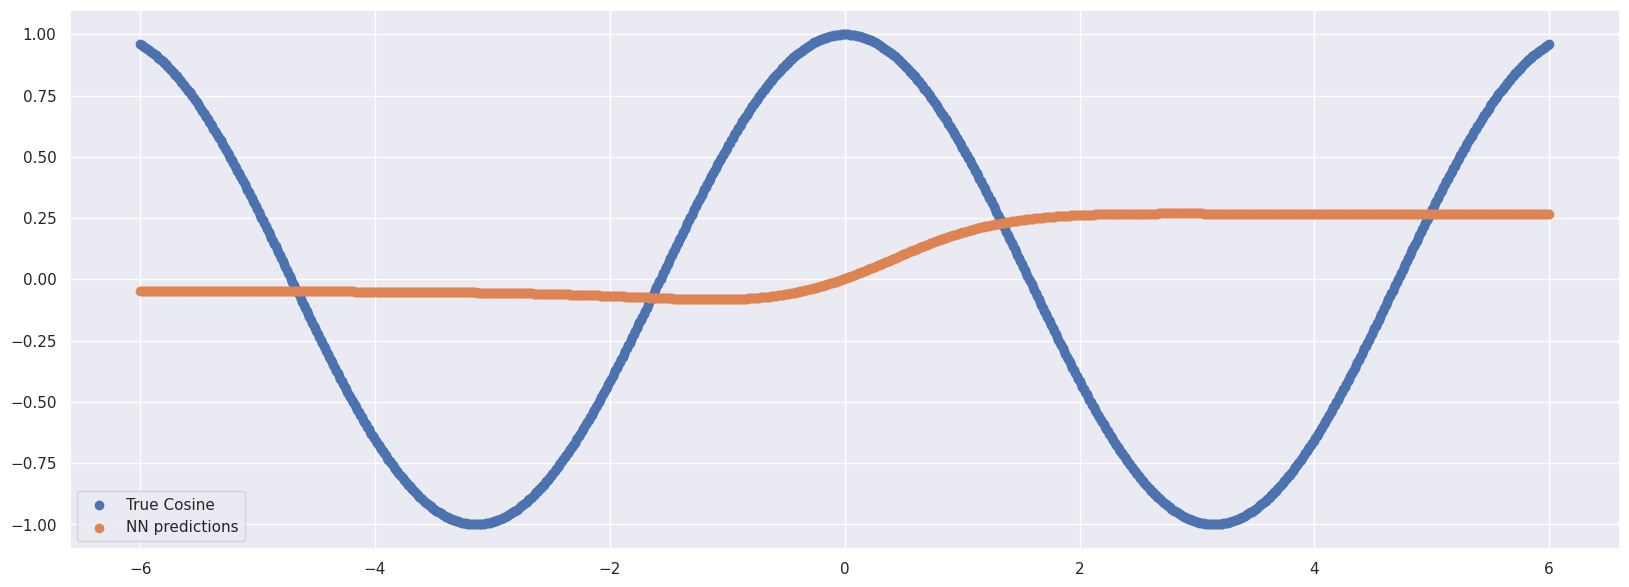

In [21]:
import matplotlib.pyplot as plt

# define test data
X_test = torch.linspace(-6, 6, 1000)
Y_test = torch.cos(X_test)

# getting prediction for test data
nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.detach().numpy()

# visualizing data and NN predictions
plt.figure(figsize=(20,7))
plt.scatter(x=X_test, y=Y_test, label='True Cosine');
plt.scatter(x=X_test, y=nn_prediction, label='NN predictions');
plt.legend()

The result we got is expected, because our neural network is not yet trained. Let's train it. But first, let's talk about how the training is done in detail.

## Training of Neural Networks



Let's write the train function for training our network

In [22]:
import tqdm
from tqdm.auto import tqdm

def train(model, dataloader, criterion, optimizer, num_epoch):
    '''
    args:
        model - our neural network model
        dataloader — structure which yields batches of data
        criterion - loss function from `torch.nn` module
        optimizer - optimizer from `torch.optim` module
        num_epoch - number of training epochs
    '''
    for t in tqdm(range(num_epoch)):
        for X, y in dataloader:
            # getting our model's predictions on current batch
            y_pred = model(X)

            # getting loss value
            loss = criterion(y_pred, y)

            # zeroing previous gradient data
            optimizer.zero_grad()
            # calculate new gradients
            loss.backward()
            # optimization step
            optimizer.step()

    return model

Let's define our network again:

In [23]:
NN = nn.Sequential(nn.Linear(1, 5, bias=True),
                   nn.Tanh(),
                   nn.Linear(5, 5, bias=True),
                   nn.Tanh(),
                   nn.Linear(5, 1, bias=True),
                   nn.Tanh())


Now let's define loss function, optimizer, dataloader and train our network:

In [24]:
# loss function
criterion = torch.nn.MSELoss()
# optimizer
optimizer = torch.optim.SGD(NN.parameters(), lr=1e-2)
# dataloader
train_loader = torch.utils.data.DataLoader(list(zip(X, Y)), batch_size=1024, shuffle=True)

NN = train(NN, train_loader, criterion, optimizer, 1000)

  0%|          | 0/1000 [00:00<?, ?it/s]

And look at the results:

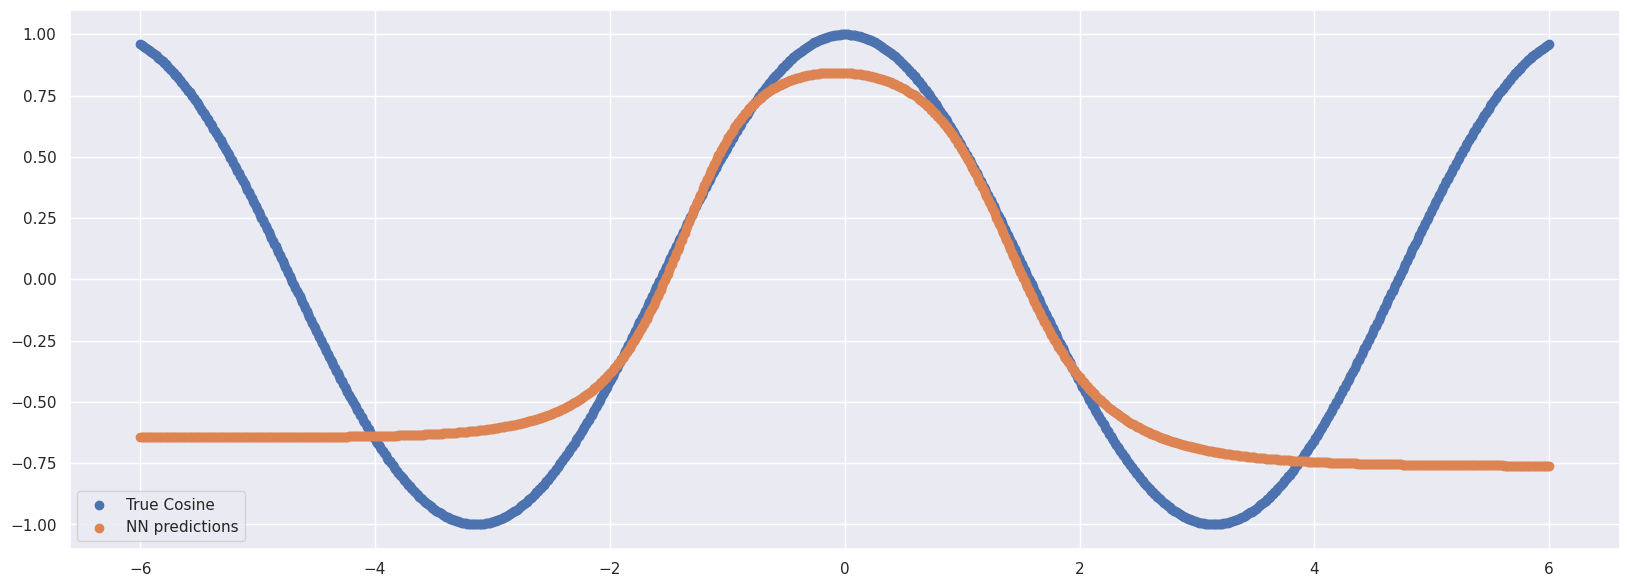

In [25]:
nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test, y=Y_test, label='True Cosine');
plt.scatter(x=X_test, y=nn_prediction, label='NN predictions');
plt.legend()

## Neural network as nn.Module

Before we've defined our network using nn.Sequential:

In [26]:
NN = nn.Sequential(nn.Linear(1, 5, bias=True),
                   nn.Tanh(),
                   nn.Linear(5, 5, bias=True),
                   nn.Tanh(),
                   nn.Linear(5, 1, bias=True),
                   nn.Tanh())

Sometimes such a simple structure as `Sequential` is not enough to create quite complex models. Sometimes this is due to the fact that several independent branches need to be created in the calculations, sometimes - due to the need to log the history of calculations. There may be other reasons. In any case, it would be nice to be able to interfere with the results of intermediate calculations. For this, there is a more flexible way to work with neural networks in Pytorch - this is writing your own classes inherited from the `nn.Module` class.

The description of the forward pass through such a block is done via redefining `forward` function.

In [27]:
class Net(nn.Module):
    def __init__(self, dim=1):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(dim, 5)
        self.tanh1 = nn.Tanh()

        self.fc2 = nn.Linear(5, 5)
        self.tanh2 = nn.Tanh()

        self.fc3 = nn.Linear(5, 1)


    def forward(self, x):

        x = self.fc1(x)
        x = self.tanh1(x)

        x = self.fc2(x)
        x = self.tanh2(x)

        x = self.fc3(x)
        x = torch.clamp(x, min=-1.0, max=1.0)
        return x

In [28]:
NN = Net(1)

Training of such a model is done the same way as before. Let's train the model using our `train` function:

In [29]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(NN.parameters(), lr=1e-2)
train_loader = torch.utils.data.DataLoader(list(zip(X, Y)), batch_size=16, shuffle=True)

NN = train(NN, train_loader, criterion, optimizer, 100)

  0%|          | 0/100 [00:00<?, ?it/s]

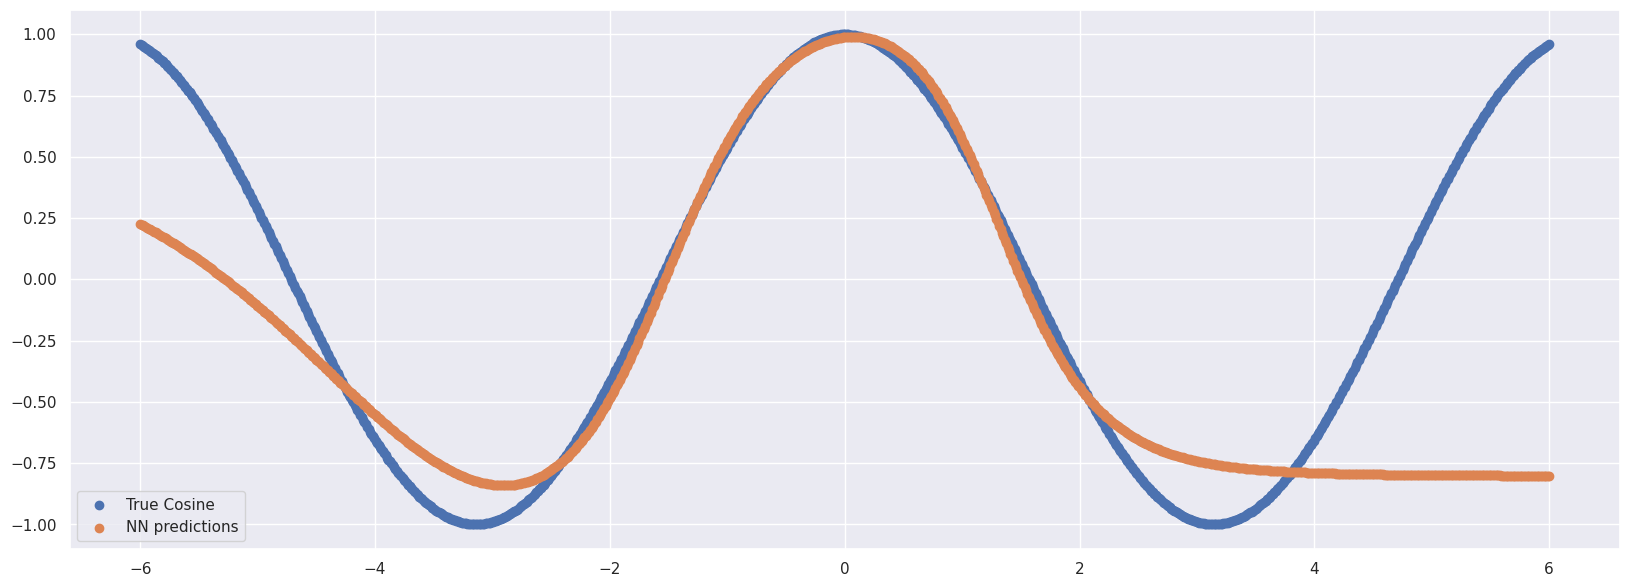

In [30]:
nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test, y=Y_test, label='True Cosine');
plt.scatter(x=X_test, y=nn_prediction, label='NN predictions');
plt.legend()

## Using GPU

Using GPU is a mandatory attribute of working with deep neural networks. GPUs allow for fast, efficient parallel computations. `Pytorch` has an interface for transferring computations to a video card. To perform this transfer, both the model parameters and the input data must be transferred to the video card.

First of all, you need to check whether the video card is available for computations. In Google Colab, you need to select the "Runtime" tab in the main menu, select the "Change runtime" command there, then select "GPU" as the hardware accelerator. After that, you can use the following command to check the availability of the GPU:

In [31]:
import torch
# this command checks if GPU is available
torch.cuda.is_available()

True

In [32]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Now we can perform calculations on the GPU. Transferring tensors and modules to the GPU is done using the functions `.to(device)`, or `.cuda()`

**Note:** we have to duplicate the definitions of the main functions because the runtime is rebooted after connecting the GPU

In [33]:
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, dim):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(dim, 5)
        self.tanh1 = nn.Tanh()

        self.fc2 = nn.Linear(5, 5)
        self.tanh2 = nn.Tanh()

        self.fc3 = nn.Linear(5, 1)


    def forward(self, x):

        x = self.fc1(x)
        x = self.tanh1(x)

        x = self.fc2(x)
        x = self.tanh2(x)

        x = self.fc3(x)
        return x

In [34]:
NN = Net(1)
NN = NN.to(device) # transferring to device

In [35]:
import tqdm
from tqdm.auto import tqdm

def train(model, dataloader, criterion, optimizer, num_epoch):
    '''
    args:
        model - our neural network model
        dataloader — structure which yields batches of data
        criterion - loss function from `torch.nn` module
        optimizer - optimizer from `torch.optim` module
        num_epoch - number of training epochs
    '''
    for t in tqdm(range(num_epoch)):
        for X, y in dataloader:
            # getting our model's predictions on current batch
            y_pred = model(X.to(device))

            # getting loss value
            loss = criterion(y_pred, y.to(device))

            # zeroing previous gradient data
            optimizer.zero_grad()
            # calculate new gradients
            loss.backward()
            # optimization step
            optimizer.step()

    return model

Let's generate our data again:

In [41]:
X = (torch.rand(1000, 1) * 12) - 6
Y = torch.cos(X)

And train our network on GPU:

In [54]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(NN.parameters(), lr=1e-2)
train_loader = torch.utils.data.DataLoader(list(zip(X, Y)), batch_size=16, shuffle=True)

NN = train(NN, train_loader, criterion,optimizer, 200)

  0%|          | 0/200 [00:00<?, ?it/s]

Now in order to convert tensors to `numpy` format we need to add `.cpu()` to our `.detach().numpy()` commands:

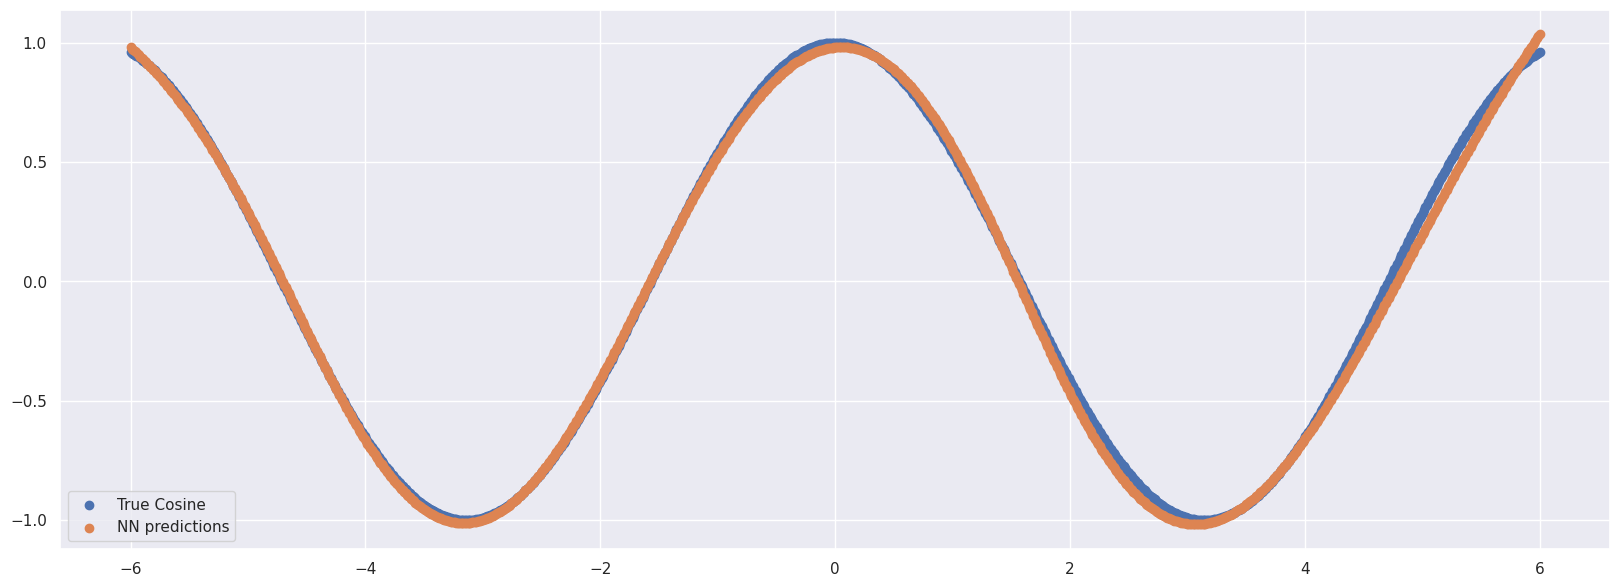

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

X_test = torch.linspace(-6, 6, 1000).to(device)
Y_test = torch.cos(X_test)

nn_prediction = NN(X_test.view(-1, 1))
nn_prediction = nn_prediction.cpu().detach().numpy()

plt.figure(figsize=(20,7))
plt.scatter(x=X_test.cpu(), y=Y_test.cpu(), label='True Cosine');
plt.scatter(x=X_test.cpu(), y=nn_prediction, label='NN predictions');
plt.legend()